# Plot ImageNet Debug Curves

This notebook loads the three `summary.csv` files under `files/debug/` and plots `FID` and `IS` versus the number of sampling steps.

In [16]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "axes.grid": False,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})

In [17]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

summary_paths = {
    "analytic": repo_root / "files/debug/fid5k_plain_dit_native_velocity_analytic_imagenet/summary.csv",
    "data": repo_root / "files/debug/fid5k_plain_dit_native_velocity_data_imagenet/summary.csv",
    "ddpm": repo_root / "files/debug/fid5k_plain_dit_psample_imagenet/summary.csv",
}

for name, path in summary_paths.items():
    print(f"{name}: {path}")
    print("  exists:", path.exists())

analytic: /projets/Ymohammadi/imeanflow/files/debug/fid5k_plain_dit_native_velocity_analytic_imagenet/summary.csv
  exists: True
data: /projets/Ymohammadi/imeanflow/files/debug/fid5k_plain_dit_native_velocity_data_imagenet/summary.csv
  exists: True
ddpm: /projets/Ymohammadi/imeanflow/files/debug/fid5k_plain_dit_psample_imagenet/summary.csv
  exists: True


In [18]:
def load_summary(csv_path):
    rows = []
    with csv_path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({
                "num_steps": int(row["num_steps"]),
                "fid": float(row["fid"]),
                "is": float(row["is"]),
            })
    return sorted(rows, key=lambda item: item["num_steps"])

series = {name: load_summary(path) for name, path in summary_paths.items()}
series

{'analytic': [{'num_steps': 1,
   'fid': 361.3526650343107,
   'is': 1.2761792085933044},
  {'num_steps': 2, 'fid': 331.24496099498595, 'is': 1.4997319464811276},
  {'num_steps': 4, 'fid': 212.9991634044959, 'is': 6.030076014546232},
  {'num_steps': 8, 'fid': 51.51809086181697, 'is': 48.496502100108785},
  {'num_steps': 16, 'fid': 16.21651327134157, 'is': 112.40894234636039},
  {'num_steps': 32, 'fid': 9.596275677568826, 'is': 140.03969594629416},
  {'num_steps': 64, 'fid': 8.203125809418566, 'is': 150.66537739300213},
  {'num_steps': 250, 'fid': 7.754879171895254, 'is': 159.04077511487105}],
 'data': [{'num_steps': 1,
   'fid': 249.94061254799757,
   'is': 2.7657490658048918},
  {'num_steps': 2, 'fid': 156.58341798741066, 'is': 5.1549974140789185},
  {'num_steps': 4, 'fid': 77.84384469408133, 'is': 30.735848714520877},
  {'num_steps': 8, 'fid': 19.996032179798306, 'is': 106.76645541968423},
  {'num_steps': 16, 'fid': 9.44366091387576, 'is': 144.81695750262233},
  {'num_steps': 32, 'fi

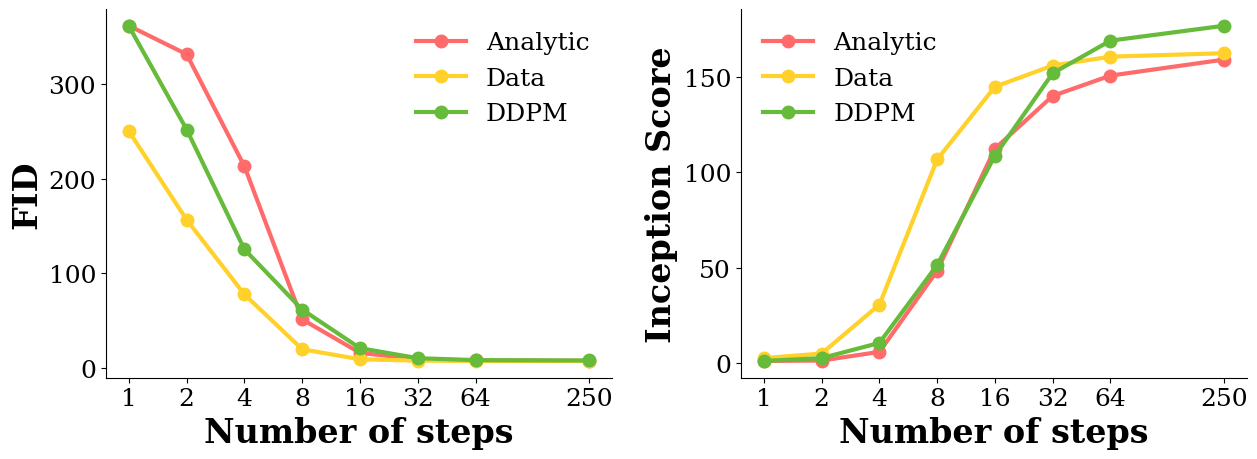

In [ ]:
colors = {
    "analytic": "#ff6b6b",
    "data": "#ffd12a",
    "ddpm": "#66bb3a",
}

labels = {
    "analytic": "Analytic",
    "data": "Data",
    "ddpm": "DDPM",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, rows in series.items():
    steps = [row["num_steps"] for row in rows]
    fid_values = [row["fid"] for row in rows]
    is_values = [row["is"] for row in rows]

    axes[0].plot(steps, fid_values, marker="o", markersize=9, linewidth=3, color=colors[name], label=labels[name])
    axes[1].plot(steps, is_values, marker="o", markersize=9, linewidth=3, color=colors[name], label=labels[name])

axes[0].set_xlabel("Number of steps", fontweight="bold")
axes[0].set_ylabel("FID", fontweight="bold")
axes[0].set_xscale("log", base=2)

axes[1].set_xlabel("Number of steps", fontweight="bold")
axes[1].set_ylabel("Inception Score", fontweight="bold")
axes[1].set_xscale("log", base=2)

for ax in axes:
    ax.legend(frameon=False)
    ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 250])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
# Optional: print the best FID from each method
for name, rows in series.items():
    best = min(rows, key=lambda row: row["fid"])
    print(f"{labels[name]}: best FID = {best['fid']:.4f} at {best['num_steps']} steps")

Analytic: best FID = 7.7549 at 250 steps
Data: best FID = 7.6570 at 250 steps
DDPM: best FID = 8.1475 at 250 steps
